# AutoGluon.TimeSeries V1.4 Cheatsheet

This notebook contains the key code snippets from the AutoGluon Time Series cheatsheet.

In [1]:
import pandas as pd
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

/home/sergio/code/autogluon/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [113]:
from process_data import *

data_dir = os.path.join(os.getcwd(), 'data')
# Define the technologies to filter
target_technologies = ['EOLICA', 'SOLAR_FOTOVOLTAICA']

filtered_dfs = process_dataset(data_dir,target_technologies)

Found 12 CSV files to process.
Processed 201403GxSEN.csv. Filtered rows: 9072
Processed 201402GxSEN.csv. Filtered rows: 11688
Processed 201407GxSEN.csv. Filtered rows: 17376
Processed 201404GxSEN.csv. Filtered rows: 13125
Processed 201401GxSEN.csv. Filtered rows: 9648
Processed 201411GxSEN.csv. Filtered rows: 24408
Processed 201405GxSEN.csv. Filtered rows: 16344
Processed 201409GxSEN.csv. Filtered rows: 21018
Processed 201412GxSEN.csv. Filtered rows: 23664
Processed 201406GxSEN.csv. Filtered rows: 18000
Processed 201408GxSEN.csv. Filtered rows: 20424
Processed 201410GxSEN.csv. Filtered rows: 20976

--- Final Result ---
Successfully merged all filtered data.
Final DataFrame shape: (205743, 13)
Unique Technologies in final DataFrame: ['EOLICA', 'SOLAR_FOTOVOLTAICA']
Categories (10, object): ['BIOMASA', 'CARBON', 'COGENERACION', 'EOLICA', ..., 'HIDRAULICA_DE_PASADA', 'MINI_HIDRAULICA_DE_PASADA', 'PETROLEO_DIESEL', 'SOLAR_FOTOVOLTAICA']


In [91]:
filtered_dfs.columns

Index(['Date', 'Year', 'Month', 'Day', 'Hour', 'Central', 'Unidad',
       'Componente', 'Generacion_MWh', 'Tecnologia', 'Clasificacion',
       'Codigo Central', 'Subsistema'],
      dtype='object')

In [114]:
filtered_dfs['Hour']= (filtered_dfs['Hour'].astype(int) - 1).apply(lambda x: f"{x:02d}:00:00")

In [163]:
filtered_dfs['Hour'].min(), filtered_dfs['Hour'].max()

('00:00:00', '24:00:00')

In [160]:
pd.to_timedelta(filtered_dfs['Hour']) 

0        0 days 00:00:00
1        0 days 01:00:00
2        0 days 02:00:00
3        0 days 03:00:00
4        0 days 04:00:00
               ...      
205738   0 days 19:00:00
205739   0 days 20:00:00
205740   0 days 21:00:00
205741   0 days 22:00:00
205742   0 days 23:00:00
Name: Hour, Length: 205743, dtype: timedelta64[ns]

In [161]:
filtered_dfs['timestamp'] = pd.to_datetime(filtered_dfs['Date'],dayfirst=True) + pd.to_timedelta(filtered_dfs['Hour'])

In [162]:
filtered_dfs['timestamp']

0        2014-03-01 00:00:00
1        2014-03-01 01:00:00
2        2014-03-01 02:00:00
3        2014-03-01 03:00:00
4        2014-03-01 04:00:00
                 ...        
205738   2014-10-31 19:00:00
205739   2014-10-31 20:00:00
205740   2014-10-31 21:00:00
205741   2014-10-31 22:00:00
205742   2014-10-31 23:00:00
Name: timestamp, Length: 205743, dtype: datetime64[ns]

## Preparing Data

AutoGluon can generate forecasts for datasets consisting of **multiple univariates** time series. Here we use the M4 Competition Daily dataset to demonstrate how to do forecasting with AutoGluon. 

The data typically requires two parts: **raw data** (time series) and **static features** (metadata).

In [166]:
filtered_dfs["Tecnologia"]=filtered_dfs["Tecnologia"].cat.remove_unused_categories()

In [167]:
filtered_dfs.groupby("Tecnologia",observed=True)["Generacion_MWh"].sum().sort_values(ascending=False)

Tecnologia
EOLICA                1.330534e+06
SOLAR_FOTOVOLTAICA    4.197053e+05
Name: Generacion_MWh, dtype: float64

In [168]:
filtered_dfs['Tecnologia'].value_counts()

Tecnologia
EOLICA                104794
SOLAR_FOTOVOLTAICA    100949
Name: count, dtype: int64

In [169]:
generacion=filtered_dfs[["Codigo Central","timestamp","Generacion_MWh"]]

In [219]:
generacion

,Codigo Central,timestamp,Generacion_MWh
0,Canela,2014-03-01 00:00:00,4.40
1,Canela,2014-03-01 01:00:00,7.00
2,Canela,2014-03-01 02:00:00,5.60
3,Canela,2014-03-01 03:00:00,4.50
4,Canela,2014-03-01 04:00:00,2.30
...,...,...,...
205738,PAS3_Solar,2014-10-31 19:00:00,1.02
205739,PAS3_Solar,2014-10-31 20:00:00,0.00
205740,PAS3_Solar,2014-10-31 21:00:00,0.00
205741,PAS3_Solar,2014-10-31 22:00:00,0.00


In [220]:
generacion_static=filtered_dfs[["Codigo Central","Tecnologia"]].drop_duplicates().reset_index(drop=True)

In [221]:
print("Raw Data Head:")
print(generacion.head())
print("\nStatic Features Head:")
print(generacion_static.head())

Raw Data Head:
  Codigo Central           timestamp  Generacion_MWh
0         Canela 2014-03-01 00:00:00             4.4
1         Canela 2014-03-01 01:00:00             7.0
2         Canela 2014-03-01 02:00:00             5.6
3         Canela 2014-03-01 03:00:00             4.5
4         Canela 2014-03-01 04:00:00             2.3

Static Features Head:
       Codigo Central Tecnologia
0              Canela     EOLICA
1            Canela 2     EOLICA
2  Parque Eólico Lebu     EOLICA
3      Eólica Totoral     EOLICA
4       Monte Redondo     EOLICA


In [222]:
generacion_static.groupby("Tecnologia",observed=True).size()

Tecnologia
EOLICA                17
SOLAR_FOTOVOLTAICA    19
dtype: int64

### Convert Raw Data into a TimeSeriesDataFrame

Convert your raw data into the format required by AutoGluon: `TimeSeriesDataFrame`.

In [223]:
# from autogluon.timeseries import TimeSeriesDataFrame # Already imported above
data = TimeSeriesDataFrame(
    generacion,
    id_column="Codigo Central",
    timestamp_column="timestamp",
    static_features=generacion_static,  # Optional metadata/covariates
)

print("Processed Training Data:")
print(data.head(5))

Processed Training Data:
                             Generacion_MWh
item_id timestamp                          
Canela  2014-03-01 00:00:00             4.4
        2014-03-01 01:00:00             7.0
        2014-03-01 02:00:00             5.6
        2014-03-01 03:00:00             4.5
        2014-03-01 04:00:00             2.3


In [226]:
data.groupby("item_id",observed=True).count()

,Generacion_MWh
item_id,
Canela,8377
Canela 2,8377
El Arrayán,4992
EÓLICA VALLE DE LOS VIENTOS_Eólico,7272
Eólica Los Cururos,4488
Eólica Negrete,3576
Eólica Taltal,1728
Eólica Totoral,8377
HUAYCA1,7295


In [227]:
data.convert_frequency(freq="h")

Generacion_MWh
item_id        timestamp                          
Canela         2014-01-01 00:00:00             4.3
               2014-01-01 01:00:00             2.3
               2014-01-01 02:00:00             2.4
               2014-01-01 03:00:00             1.6
               2014-01-01 04:00:00             1.5
...                                            ...
Solar Chañares 2014-12-29 19:00:00             3.0
               2014-12-29 20:00:00             0.0
               2014-12-29 21:00:00             0.0
               2014-12-29 22:00:00             0.0
               2014-12-29 23:00:00             0.0

[221616 rows x 1 columns]

In [228]:
train_data,test_data=data.train_test_split(prediction_length=24*7)

Sorting the dataframe index before generating the train/test split.


In [229]:
train_data = train_data.fill_missing_values(method="constant", value=0.0)

In [230]:
test_data.shape,train_data.shape

((205743, 1), (199695, 1))

/tmp/ipykernel_49183/3609721456.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


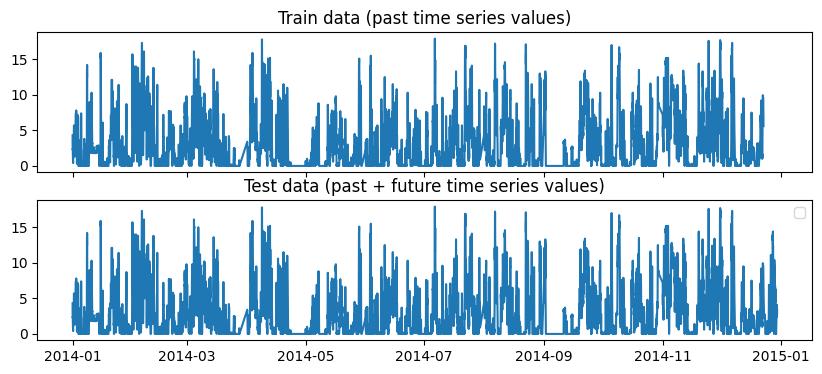

In [239]:
import matplotlib.pyplot as plt 
import numpy as np

item_id = "Canela"
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=[10, 4], sharex=True)
train_ts = train_data.loc[item_id]
test_ts = test_data.loc[item_id]
ax1.set_title("Train data (past time series values)")
ax1.plot(train_ts)
ax2.set_title("Test data (past + future time series values)")
ax2.plot(test_ts)
#for ax in (ax1, ax2):
#    ax.fill_between(np.array([train_ts.index[-1], test_ts.index[-1]]), test_ts.min(), test_ts.max(), color="C1", alpha=0.3, label="Forecast horizon")
plt.legend()
plt.show()

## Training

Train models to forecast the values in the column `target` $30$ steps into the future.

In [240]:
from autogluon.common import space

predictor = TimeSeriesPredictor(
    target="Generacion_MWh",
    prediction_length=24*7, # The number of time steps into the future to forecast
    freq="h",
    # Optional: Additional covariates that are known in the future
    # known_covariates_names=['weekday', 'month'],
).fit(
    train_data,
    presets="medium_quality"
)

Beginning AutoGluon training...
AutoGluon will save models to '/home/sergio/code/autogluon/AutogluonModels/ag-20251008_183108'
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #33~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Fri Sep 19 17:02:30 UTC 2
CPU Count:          12
GPU Count:          1
Memory Avail:       28.51 GB / 62.70 GB (45.5%)
Disk Space Avail:   89.90 GB / 217.97 GB (41.2%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'freq': 'h',
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 168,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': False,
 'target': 'Generacion_MWh',
 'verbosity': 2}

train_data with frequency 'IRREG' has b

## Predicting

Forecast `prediction_length` steps into the future starting from the end of each time series in `train_data`.

In [287]:
predictions = predictor.predict(
    train_data,
    # If you used known_covariates_names during training, pass them here:
    # known_covariates=known_covariates,
)

print("Forecasted Predictions Head:")
print(predictions.head())



data with frequency 'IRREG' has been resampled to frequency 'h'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


Forecasted Predictions Head:
                                 mean       0.1       0.2       0.3       0.4  \
item_id timestamp                                                               
Canela  2014-12-23 00:00:00  4.688838  1.606954  2.186068  3.157704  4.010948   
        2014-12-23 01:00:00  3.941049  1.149542  1.725594  2.701788  3.406575   
        2014-12-23 02:00:00  3.368709  0.828187  1.421464  2.339707  2.957683   
        2014-12-23 03:00:00  2.993097  0.546197  1.107614  1.883979  2.615952   
        2014-12-23 04:00:00  2.767438  0.313272  0.820997  1.549995  2.274814   

                                  0.5       0.6       0.7       0.8       0.9  
item_id timestamp                                                              
Canela  2014-12-23 00:00:00  4.688838  5.365121  5.944432  6.260220  7.071832  
        2014-12-23 01:00:00  3.941049  4.522313  5.144543  5.754104  6.409456  
        2014-12-23 02:00:00  3.368709  3.982740  4.606681  5.336301  5.942468  
   

In [291]:
predictions['mean'].droplevel('item_id').head()

timestamp
2014-12-23 00:00:00    4.688838
2014-12-23 01:00:00    3.941049
2014-12-23 02:00:00    3.368709
2014-12-23 03:00:00    2.993097
2014-12-23 04:00:00    2.767438
Name: mean, dtype: float64

## Model Understanding

Understand the contribution of each model.

In [250]:
leaderboard = predictor.leaderboard()
print(leaderboard)

                       model  score_val  pred_time_val  fit_time_marginal  \
0           WeightedEnsemble  -0.357228       7.696047           1.758325   
1              DirectTabular  -0.375511       0.678704          41.263305   
2        Chronos[bolt_small]  -0.383675       2.482213           0.282593   
3  TemporalFusionTransformer  -0.385022       0.127653         136.363228   
4              SeasonalNaive  -0.493544       0.082597           0.056973   
5           RecursiveTabular  -0.566420       0.983400           7.973172   
6                        ETS  -0.585225       4.324879           0.064409   
7                      Naive  -0.847771       1.923872           0.080759   
8                      Theta  -1.149390       1.261540           0.086395   

   fit_order  
0          9  
1          4  
2          7  
3          8  
4          2  
5          3  
6          5  
7          1  
8          6  


In [252]:
predictor.feature_importance(test_data)

data with frequency 'IRREG' has been resampled to frequency 'h'.
Computing feature importance
Subsample_size 50 is larger than the number of items in the data and will be ignored


,importance,stdev,n,p99_low,p99_high
Tecnologia,0.04658,0.0,5.0,0.04658,0.04658


In [251]:
predictor.leaderboard(test_data)


data with frequency 'IRREG' has been resampled to frequency 'h'.


Additional data provided, testing on additional data. Resulting leaderboard will be sorted according to test score (`score_test`).


,model,score_test,score_val,pred_time_test,pred_time_val,fit_time_marginal,fit_order
0,Chronos[bolt_small],-0.422824,-0.383675,1.664623,2.482213,0.282593,7
1,DirectTabular,-0.432894,-0.375511,0.825925,0.678704,41.263305,4
2,WeightedEnsemble,-0.442945,-0.357228,8.262190,7.696047,1.758325,9
3,TemporalFusionTransformer,-0.589703,-0.385022,0.220024,0.127653,136.363228,8
4,SeasonalNaive,-0.660492,-0.493544,0.063696,0.082597,0.056973,2
5,RecursiveTabular,-0.683393,-0.566420,1.218886,0.983400,7.973172,3
6,ETS,-0.952459,-0.585225,5.481855,4.324879,0.064409,5
7,Naive,-1.224959,-0.847771,0.095964,1.923872,0.080759,1
8,Theta,-1.477596,-1.149390,3.688117,1.261540,0.086395,6


data with frequency 'IRREG' has been resampled to frequency 'h'.


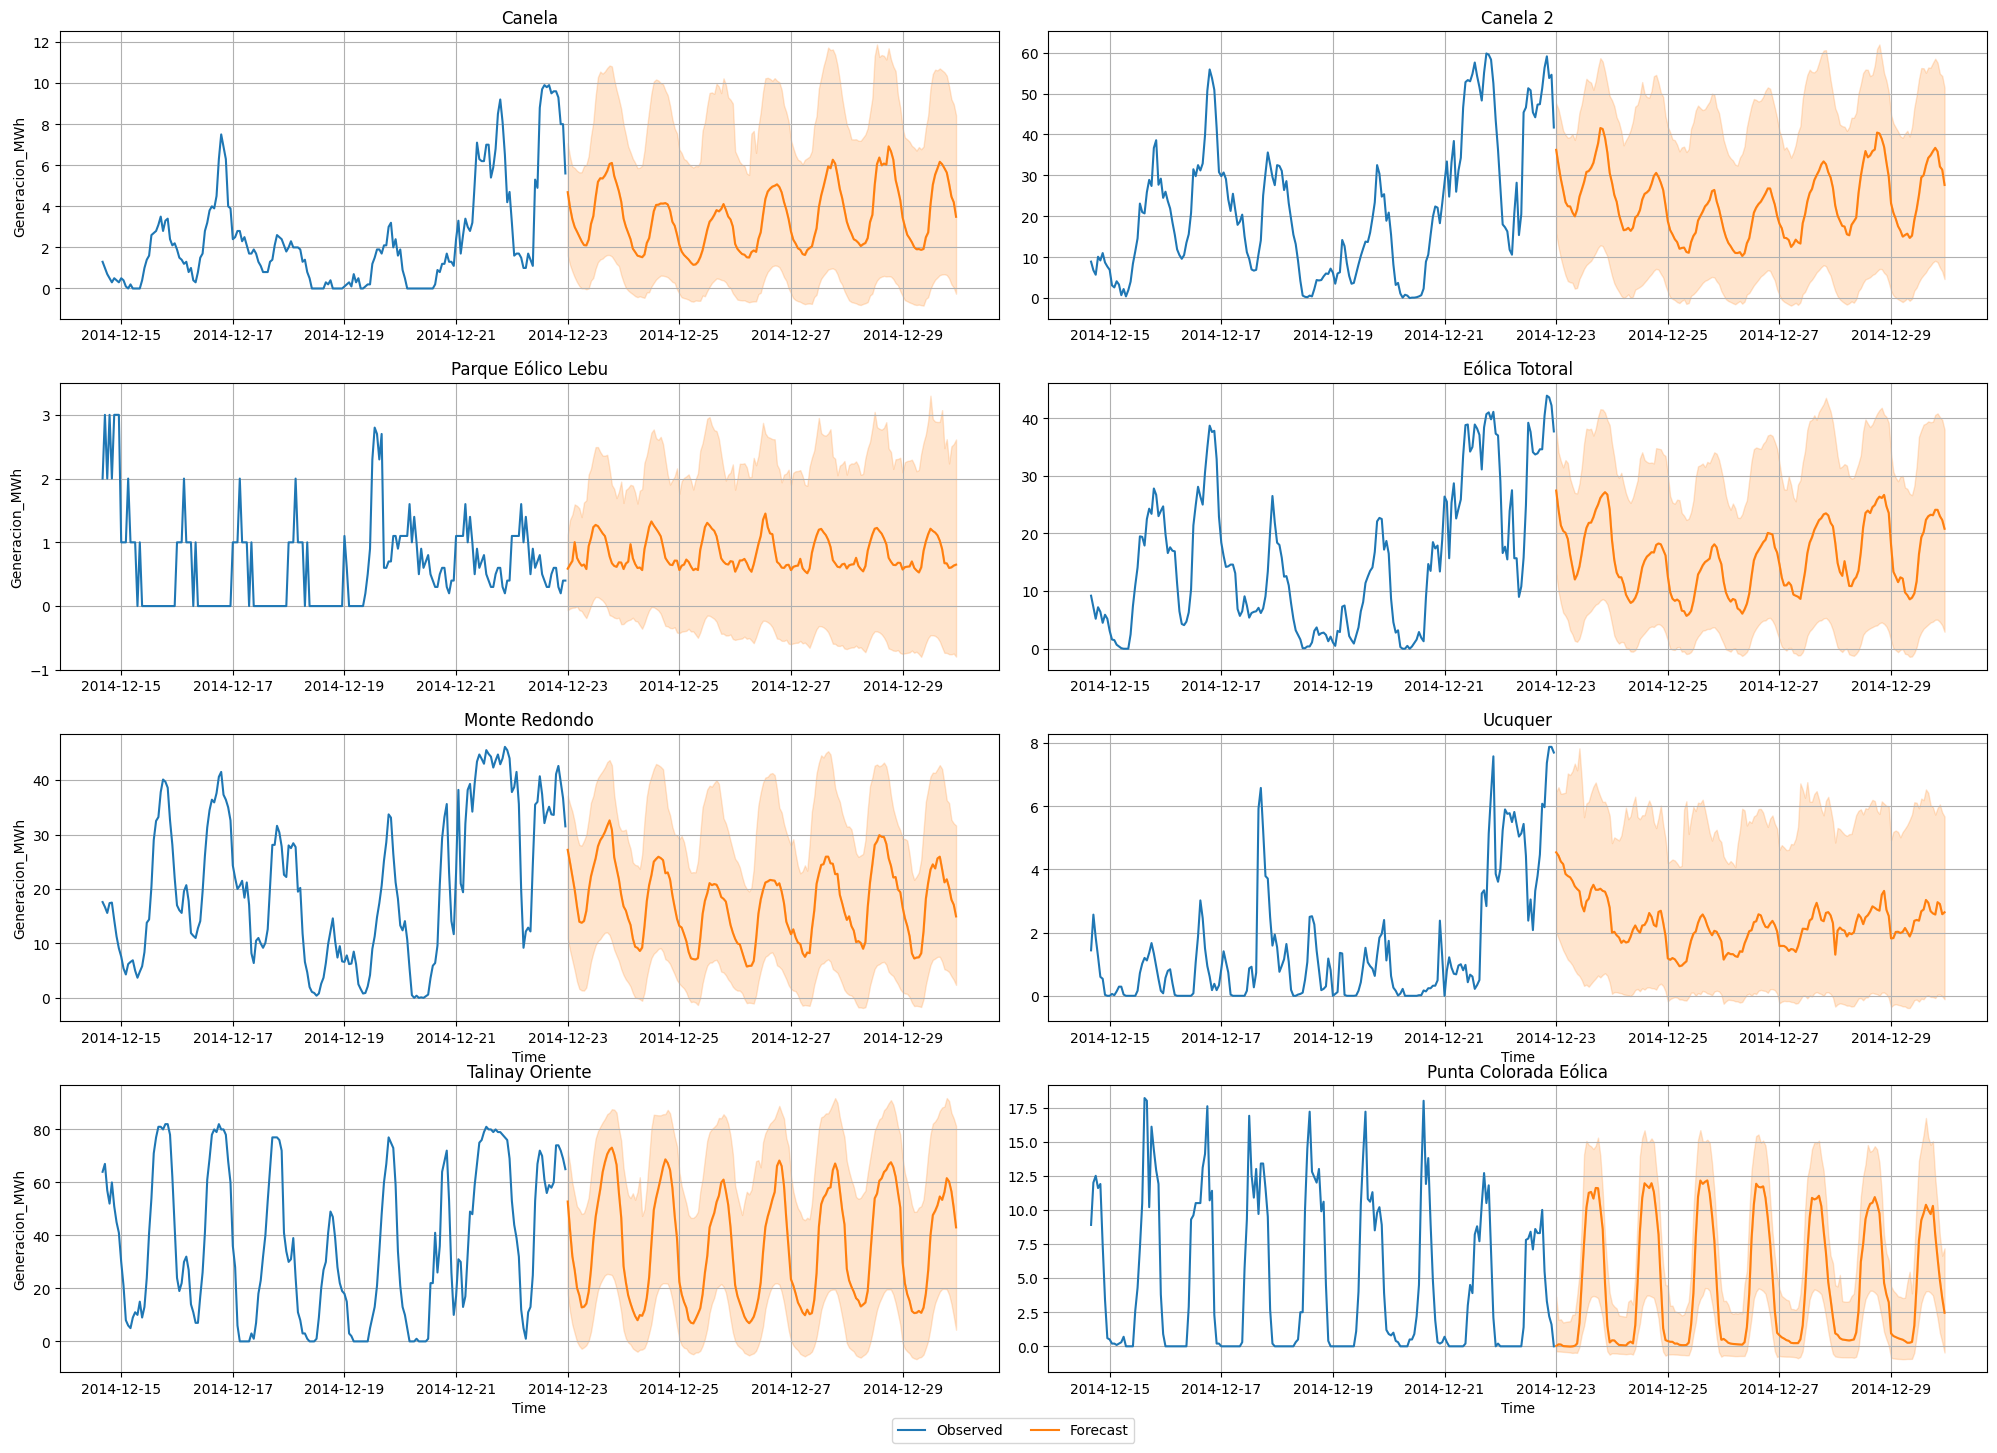

In [284]:
estaciones_eolica=train_data.static_features[train_data.static_features['Tecnologia']=='EOLICA'].index.to_list()
plt.close('all')
predictor.plot(
    data=train_data,
    predictions=predictions,
    item_ids=estaciones_eolica,
    max_history_length=200,
);
plt.show()

data with frequency 'IRREG' has been resampled to frequency 'h'.


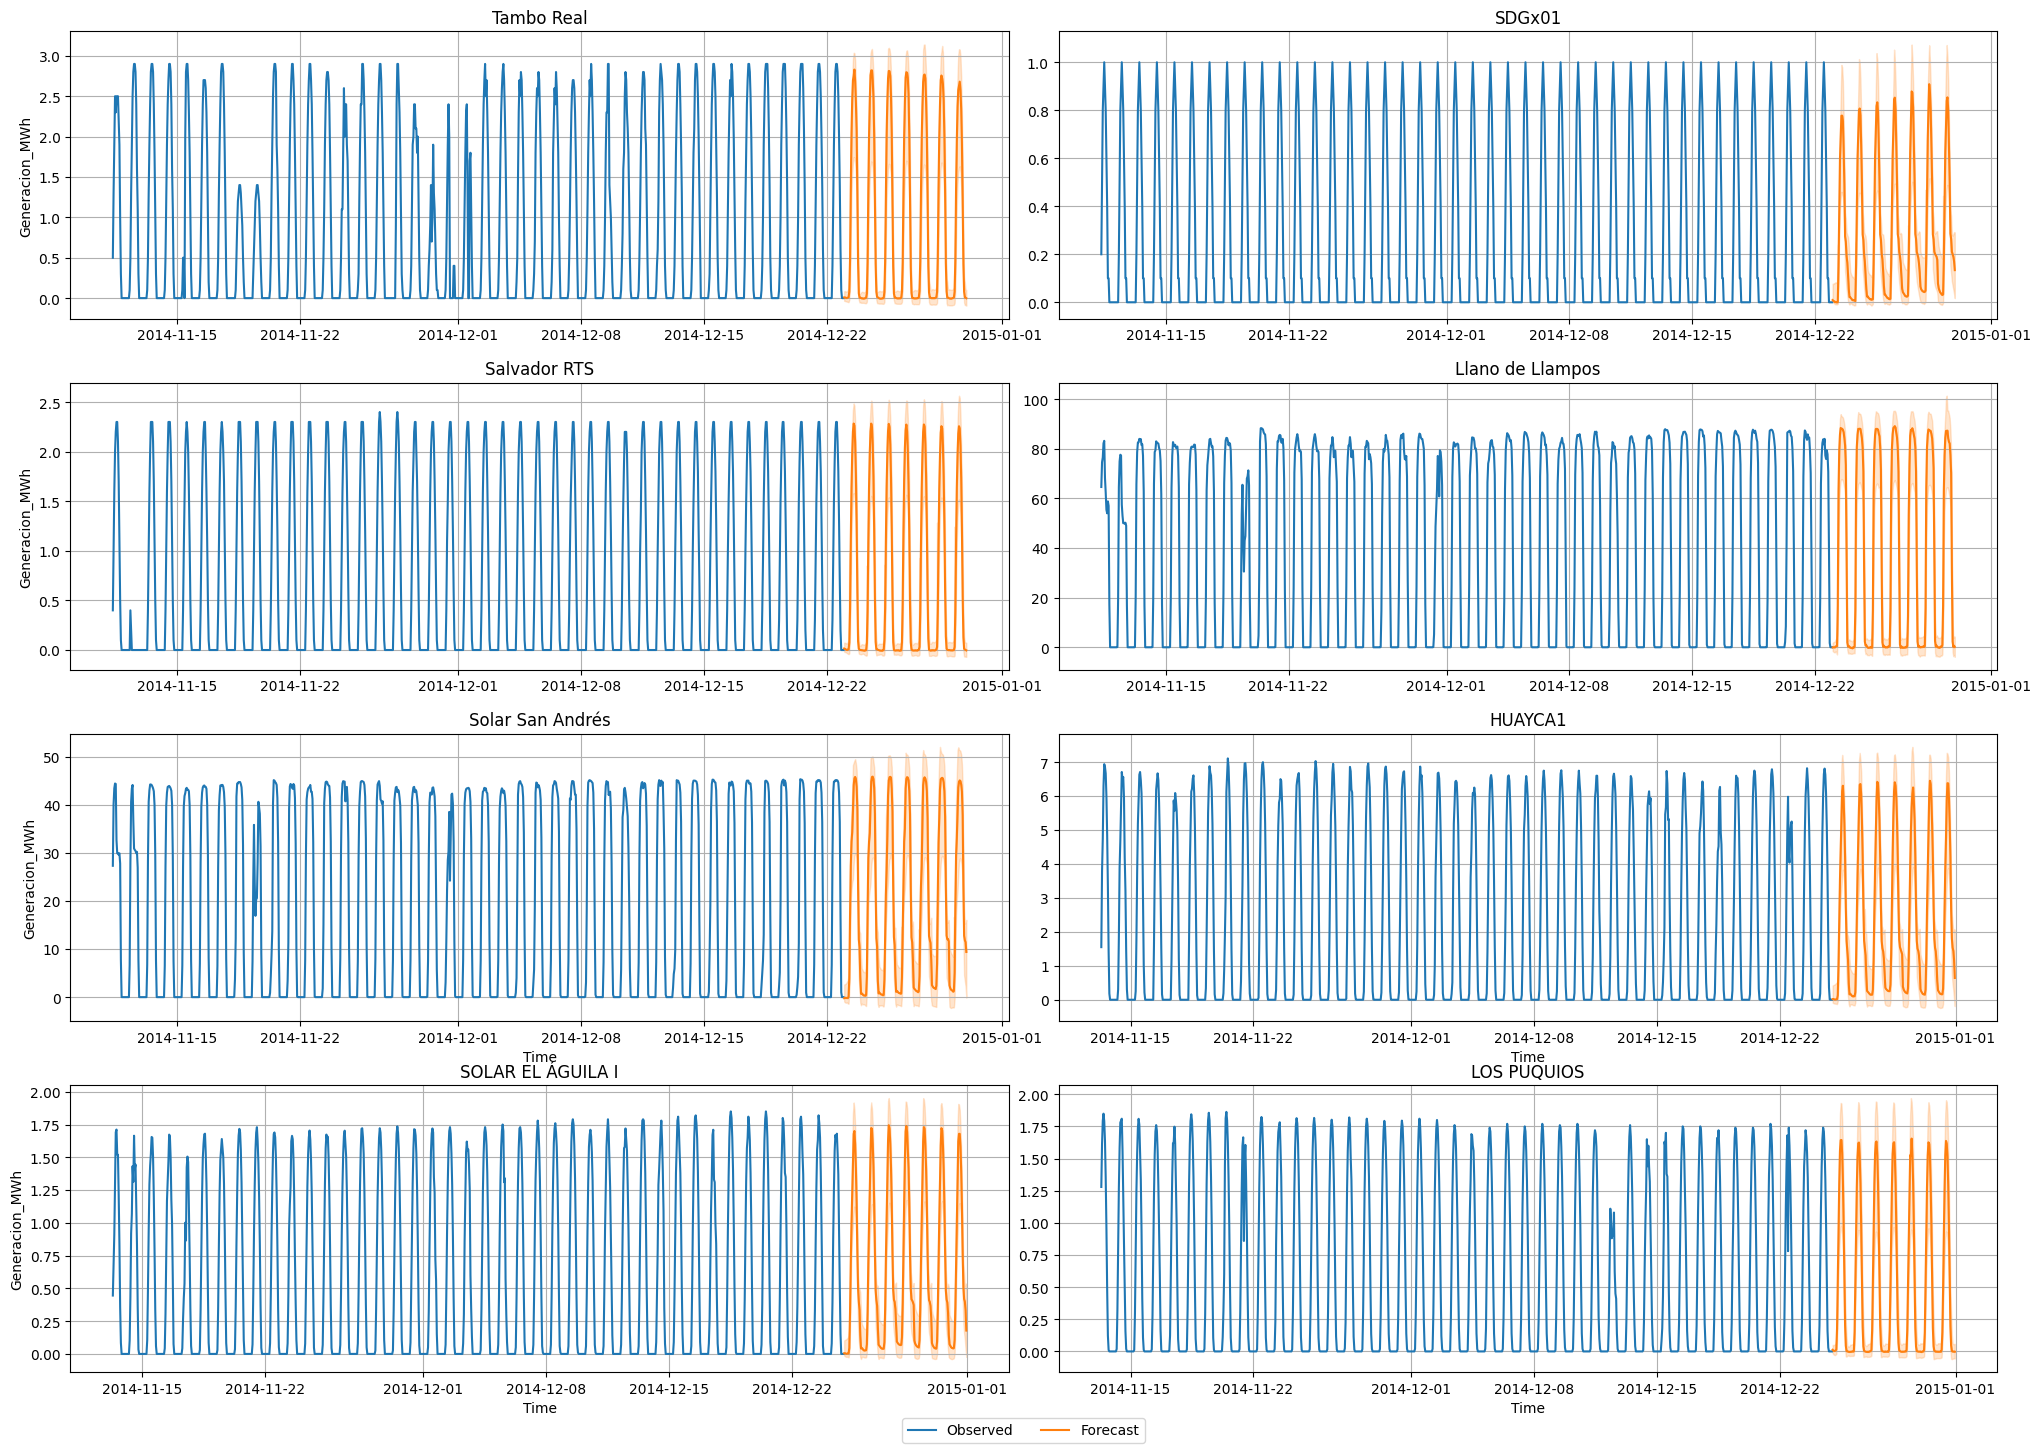

In [285]:
estaciones_solar=train_data.static_features[train_data.static_features['Tecnologia']=='SOLAR_FOTOVOLTAICA'].index.to_list()

predictor.plot(
    data=train_data,
    predictions=predictions,
    item_ids=estaciones_solar,
    max_history_length=1000,
);
plt.show()

In [286]:
test_predictions=predictor.predict(test_data)

data with frequency 'IRREG' has been resampled to frequency 'h'.


Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


In [260]:
predictor.evaluate(test_data)

data with frequency 'IRREG' has been resampled to frequency 'h'.


Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


{'WQL': np.float64(-0.4429445347197174)}

In [280]:
import sklearn.metrics
from autogluon.timeseries.metrics import TimeSeriesScorer

class R2Metric(TimeSeriesScorer):
   greater_is_better_internal = True
   optimum = 0.0

   def compute_metric(self, data_future, predictions, target, **kwargs):
      return sklearn.metrics.r2_score(y_true=data_future[target], y_pred=predictions["mean"])

In [281]:
predictor.evaluate(test_data,metrics=['WQL','MAPE','RMSE'])

data with frequency 'IRREG' has been resampled to frequency 'h'.


Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


{'WQL': np.float64(-0.4429445347197174),
 'MAPE': -4.508453263436133,
 'RMSE': np.float64(-12.272397040899559)}

In [282]:
r2 = R2Metric(prediction_length=predictor.prediction_length)
r2score = r2(
  data=test_data,
  predictions=predictions,
  target=predictor.target,
)
print(f"{r2.name_with_sign} = {r2score}")

R2Metric = 0.6118415014097741
